# Voice Keyword Detection POC — MaixCAM (CV181x)

**Pipeline:** WAV dataset → MEL Fbank → Train CNN → ONNX → cvimodel (INT8) → Deploy

- **Keywords:** sawatdee, laakorn, noise (3 classes)
- **Features:** 80-dim MEL Filterbank (98 frames × 80 bins = 1 second)
- **Model:** Small CNN classifier (~50KB INT8)
- **Board:** MaixCAM CV181x, `nn.Classifier`

In [2]:
# Step 1: Install condacolab (kernel restart)
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


In [1]:
# Step 2: Setup environment
!git clone -q https://github.com/KidBrightAI/kidbright_MAI_server server && cd server && tar -xf tools/opencv-3.4.13.tar.gz -C / && chmod +x tools/onnx2ncnn tools/spnntools
%cd server
!conda create -n kbmai python=3.10 -y -q 2>&1 | tail -1
!wget -q https://github.com/sophgo/tpu-mlir/releases/download/v1.27/tpu_mlir-1.27-py3-none-any.whl
!conda run -n kbmai pip install -q tpu_mlir*.whl 2>&1 | tail -1
!conda run -n kbmai pip install -q "setuptools<70.0.0" psutil flatbuffers "onnx==1.14.1" "onnxruntime==1.16.3" "torch==2.1.0" protobuf torchvision torchaudio 2>&1 | tail -1
!conda run -n kbmai pip install -q "onnxsim==0.4.17" "onnxslim>=0.1.71" 2>&1 | tail -1
!conda run -n kbmai pip install -q "numpy<2" librosa soundfile matplotlib 2>&1 | tail -1
!echo "Setup complete!"

/content/server
Executing transaction: ...working... done

Setup complete!


In [2]:
# Step 2b: Pull latest dataset (30 samples/class)
!cd /content/server && git pull
!ls /content/server/experiment/voice_dataset/sawatdee/ | wc -l
!ls /content/server/experiment/voice_dataset/laakorn/ | wc -l
!ls /content/server/experiment/voice_dataset/noise/ | wc -l

Already up to date.
30
30
30


## Dataset → MEL Fbank Spectrograms

Labels: ['laakorn', 'noise', 'sawatdee']
  laakorn: 30 → 30 spectrograms
  noise: 30 → 30 spectrograms
  sawatdee: 30 → 30 spectrograms


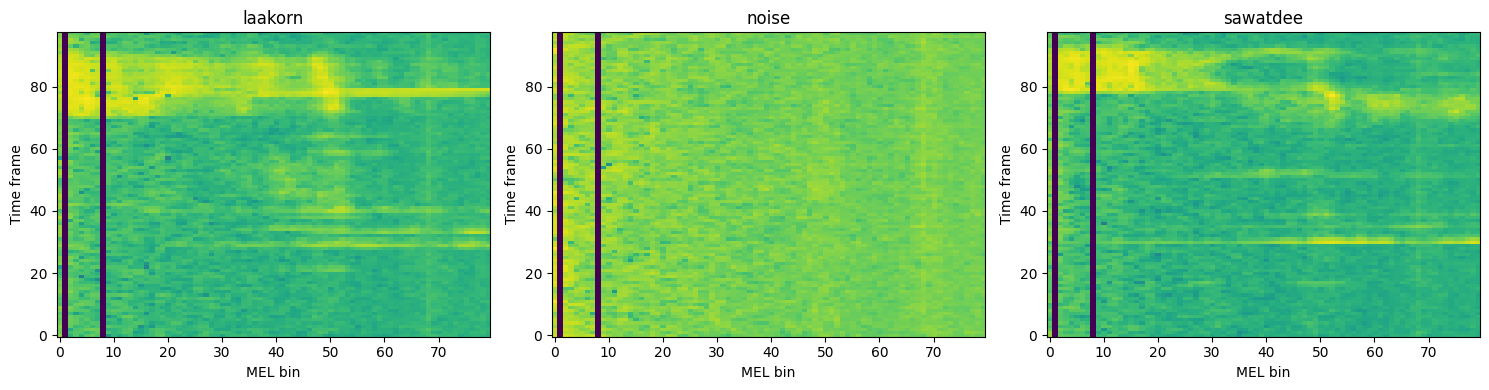


MEL spectrogram shape: (98, 80) (frames × mel_bins)


In [3]:
# Step 3: Load WAV dataset + compute MEL Fbank spectrograms
import os, glob, numpy as np, wave, struct
from PIL import Image
import matplotlib.pyplot as plt

DATASET_DIR = "/content/server/experiment/voice_dataset"
MEL_DIR = "/content/mel_dataset"
SR_TARGET = 16000
N_FFT = 512
N_MELS = 80
HOP_LENGTH = 160     # 10ms at 16KHz
WIN_LENGTH = 400     # 25ms at 16KHz
DURATION_FRAMES = 98 # ~1 second

def load_wav(path, target_sr=16000):
    """Load WAV and resample to target_sr"""
    wf = wave.open(path, 'rb')
    sr = wf.getframerate()
    data = np.frombuffer(wf.readframes(-1), dtype=np.int16).astype(np.float32)
    wf.close()
    # Resample by decimation (48000 / 16000 = 3)
    if sr != target_sr:
        ratio = sr // target_sr
        data = data[::ratio]
    # Normalize to [-1, 1]
    data = data / (np.max(np.abs(data)) + 1e-9)
    return data

def mel_filterbank(n_fft, n_mels, sr):
    """Create MEL filterbank matrix"""
    fmax = sr / 2
    mel_low = 2595 * np.log10(1 + 20 / 700)
    mel_high = 2595 * np.log10(1 + fmax / 700)
    mel_points = np.linspace(mel_low, mel_high, n_mels + 2)
    hz_points = 700 * (10 ** (mel_points / 2595) - 1)
    bins = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    fbank = np.zeros((n_mels, n_fft // 2 + 1))
    for m in range(1, n_mels + 1):
        f_left, f_center, f_right = bins[m-1], bins[m], bins[m+1]
        for k in range(f_left, f_center):
            fbank[m-1, k] = (k - f_left) / (f_center - f_left + 1e-9)
        for k in range(f_center, f_right):
            fbank[m-1, k] = (f_right - k) / (f_right - f_center + 1e-9)
    return fbank

def compute_mel_spectrogram(audio, sr=16000):
    """Compute MEL spectrogram from audio signal"""
    mel_basis = mel_filterbank(N_FFT, N_MELS, sr)
    window = np.hanning(WIN_LENGTH).astype(np.float32)

    # Pad audio to at least DURATION_FRAMES
    min_len = (DURATION_FRAMES - 1) * HOP_LENGTH + WIN_LENGTH
    if len(audio) < min_len:
        audio = np.pad(audio, (0, min_len - len(audio)))

    n_frames = min((len(audio) - WIN_LENGTH) // HOP_LENGTH + 1, DURATION_FRAMES)
    mel_spec = np.zeros((n_frames, N_MELS), dtype=np.float32)

    for i in range(n_frames):
        start = i * HOP_LENGTH
        frame = audio[start:start+WIN_LENGTH] * window
        spectrum = np.fft.rfft(frame, N_FFT)
        power = np.abs(spectrum) ** 2
        mel_spec[i] = np.dot(mel_basis, power)

    mel_spec = np.log(mel_spec + 1e-9)
    # Normalize to 0-255
    mel_spec = (mel_spec - mel_spec.min()) / (mel_spec.max() - mel_spec.min() + 1e-9) * 255
    return mel_spec.astype(np.uint8)  # (98, 80)

# Process all WAV files
labels = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d)) and d != '.DS_Store'])
print(f"Labels: {labels}")

for label in labels:
    os.makedirs(f"{MEL_DIR}/{label}", exist_ok=True)
    wav_files = sorted(glob.glob(f"{DATASET_DIR}/{label}/*.wav"))
    for wf_path in wav_files:
        audio = load_wav(wf_path, SR_TARGET)
        mel = compute_mel_spectrogram(audio, SR_TARGET)
        # Save as PNG (grayscale)
        basename = os.path.splitext(os.path.basename(wf_path))[0]
        img = Image.fromarray(mel)
        img.save(f"{MEL_DIR}/{label}/{basename}.png")
    print(f"  {label}: {len(wav_files)} → {len(os.listdir(f'{MEL_DIR}/{label}'))} spectrograms")

# Show samples
fig, axes = plt.subplots(1, len(labels), figsize=(15, 4))
for i, label in enumerate(labels):
    img = Image.open(f"{MEL_DIR}/{label}/{label}_00.png")
    axes[i].imshow(np.array(img), aspect='auto', origin='lower', cmap='viridis')
    axes[i].set_title(label)
    axes[i].set_xlabel("MEL bin")
    axes[i].set_ylabel("Time frame")
plt.tight_layout()
plt.savefig("mel_samples.png", dpi=100)
plt.show()
print(f"\nMEL spectrogram shape: {mel.shape} (frames × mel_bins)")

## Train CNN Classifier

In [4]:
# Step 4: Define CNN model + Train (STRATIFIED split)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import os, glob, random

# --- Model ---
class VoiceKwsCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# --- Dataset (keeps list of (path, label_idx) in order) ---
class MelDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


# --- Training ---
MEL_DIR = "/content/mel_dataset"
labels = sorted([d for d in os.listdir(MEL_DIR) if os.path.isdir(f"{MEL_DIR}/{d}")])
num_classes = len(labels)
print(f"Labels: {labels}, Classes: {num_classes}")

# STRATIFIED SPLIT — 80/20 per class
random.seed(42)
train_samples, val_samples = [], []
for i, label in enumerate(labels):
    class_files = sorted(glob.glob(f"{MEL_DIR}/{label}/*.png"))
    random.shuffle(class_files)
    split = int(0.8 * len(class_files))
    train_class = [(f, i) for f in class_files[:split]]
    val_class = [(f, i) for f in class_files[split:]]
    train_samples.extend(train_class)
    val_samples.extend(val_class)
    print(f"  {label}: train={len(train_class)}, val={len(val_class)}")

random.shuffle(train_samples)
random.shuffle(val_samples)
print(f"\nTotal: train={len(train_samples)}, val={len(val_samples)}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_ds = MelDataset(train_samples, transform)
val_ds = MelDataset(val_samples, transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VoiceKwsCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,} ({total_params*4/1024:.1f} KB FP32)")

EPOCHS = 100
best_acc = 0
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out = model(imgs)
        loss = criterion(out, lbls)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, pred = out.max(1)
        train_correct += pred.eq(lbls).sum().item()
        train_total += lbls.size(0)
    train_acc = train_correct / train_total

    # Per-class validation
    model.eval()
    per_class_correct = [0] * num_classes
    per_class_total = [0] * num_classes
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            _, pred = out.max(1)
            for t, p in zip(lbls.cpu().numpy(), pred.cpu().numpy()):
                per_class_total[t] += 1
                if t == p:
                    per_class_correct[t] += 1

    val_correct = sum(per_class_correct)
    val_total = sum(per_class_total)
    val_acc = val_correct / val_total if val_total > 0 else 0

    if val_acc >= best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "/content/voice_kws_best.pt")

    if (epoch + 1) % 10 == 0:
        per_class_str = " | ".join(
            f"{labels[i]}={per_class_correct[i]}/{per_class_total[i]}"
            for i in range(num_classes))
        print(f"E{epoch+1:3d} loss={train_loss/len(train_loader):.3f} "
              f"train_acc={train_acc:.2%} val_acc={val_acc:.2%} | {per_class_str}")

print(f"\nBest val_acc: {best_acc:.2%}")
print(f"Saved: /content/voice_kws_best.pt")

Labels: ['laakorn', 'noise', 'sawatdee'], Classes: 3
  laakorn: train=24, val=6
  noise: train=24, val=6
  sawatdee: train=24, val=6

Total: train=72, val=18
Model params: 140,451 (548.6 KB FP32)
E 10 loss=0.249 train_acc=93.06% val_acc=94.44% | laakorn=5/6 | noise=6/6 | sawatdee=6/6
E 20 loss=0.222 train_acc=94.44% val_acc=66.67% | laakorn=0/6 | noise=6/6 | sawatdee=6/6
E 30 loss=0.084 train_acc=98.61% val_acc=100.00% | laakorn=6/6 | noise=6/6 | sawatdee=6/6
E 40 loss=0.029 train_acc=100.00% val_acc=100.00% | laakorn=6/6 | noise=6/6 | sawatdee=6/6
E 50 loss=0.046 train_acc=98.61% val_acc=94.44% | laakorn=5/6 | noise=6/6 | sawatdee=6/6
E 60 loss=0.049 train_acc=100.00% val_acc=100.00% | laakorn=6/6 | noise=6/6 | sawatdee=6/6
E 70 loss=0.025 train_acc=100.00% val_acc=94.44% | laakorn=5/6 | noise=6/6 | sawatdee=6/6
E 80 loss=0.017 train_acc=100.00% val_acc=94.44% | laakorn=5/6 | noise=6/6 | sawatdee=6/6
E 90 loss=0.018 train_acc=100.00% val_acc=94.44% | laakorn=5/6 | noise=6/6 | sawatdee

## Export ONNX → cvimodel

In [5]:
# Step 5: Export to ONNX
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "onnx"])

import torch

labels = sorted([d for d in os.listdir("/content/mel_dataset") if os.path.isdir(f"/content/mel_dataset/{d}")])
num_classes = len(labels)

model = VoiceKwsCNN(num_classes)
model.load_state_dict(torch.load("/content/voice_kws_best.pt", map_location="cpu"))
model.eval()

dummy = torch.randn(1, 3, 98, 80)
torch.onnx.export(model, dummy, "/content/voice_kws.onnx",
                  input_names=["input"], output_names=["output"],
                  opset_version=16, dynamo=False)
print(f"ONNX exported: voice_kws.onnx")
!ls -lh /content/voice_kws.onnx

/tmp/ipykernel_1640/1457018375.py:15: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, "/content/voice_kws.onnx",


ONNX exported: voice_kws.onnx
-rw-r--r-- 1 root root 550K Apr 10 06:29 /content/voice_kws.onnx


In [6]:
# Step 6: Convert ONNX → cvimodel (tpu-mlir)
!conda run -n kbmai model_transform.py \
  --model_name voice_kws \
  --model_def /content/voice_kws.onnx \
  --input_shapes [[1,3,98,80]] \
  --mean "127.5,127.5,127.5" \
  --scale "0.0078125,0.0078125,0.0078125" \
  --pixel_format rgb \
  --channel_format nchw \
  --test_input /content/mel_dataset/sawatdee/sawatdee_00.png \
  --test_result voice_kws_top_outputs.npz \
  --tolerance 0.99,0.99 \
  --mlir voice_kws.mlir

2026/04/10 06:29:35 - INFO : TPU-MLIR v1.27-20260206
2026/04/10 06:29:35 - INFO : 
	 _____________________________________________________ 
	| preprocess:                                           |
	|   (x - mean) * scale                                  |
	'-------------------------------------------------------'
  config Preprocess args : 
	resize_dims           : same to net input dims
	keep_aspect_ratio     : False
	keep_ratio_mode       : letterbox
	pad_value             : 0
	pad_type              : center
	--------------------------
	mean                  : [127.5, 127.5, 127.5]
	scale                 : [0.0078125, 0.0078125, 0.0078125]
	--------------------------
	pixel_format          : rgb
	channel_format        : nchw
	yuv_type              : 

2026/04/10 06:29:41 - INFO : Input_shape assigned
2026/04/10 06:29:41 - INFO : ConstantFolding finished
2026/04/10 06:29:41 - INFO : skip_fuse_bn:False
2026/04/10 06:29:41 - INFO : Onnxsim opt finished
2026/04/10 06:29:41 - INFO : Con

In [7]:
# Step 7: Calibration (use MEL spectrogram images)
!conda run -n kbmai run_calibration.py voice_kws.mlir \
  --dataset /content/mel_dataset/sawatdee \
  --input_num 10 \
  -o voice_kws_cali_table

TPU-MLIR v1.27-20260206
2026/04/10 06:29:56 - INFO : 
  load_config Preprocess args : 
	resize_dims           : [98, 80]
	keep_aspect_ratio     : False
	keep_ratio_mode       : letterbox
	pad_value             : 0
	pad_type              : center
	input_dims            : [98, 80]
	--------------------------
	mean                  : [127.5, 127.5, 127.5]
	scale                 : [0.0078125, 0.0078125, 0.0078125]
	--------------------------
	pixel_format          : rgb
	channel_format        : nchw
	yuv_type              : 

input_num = 10, ref = 10
real input_num = 10
auto tune end, run time:2.6068878173828125


activation_collect_and_calc_th for sample: 0:   0%|          | 0/10 [00:00<?, ?it/s][                                                  ] 0%                                                  ] 0%#                                       ] 22%#          

In [8]:
# Step 8: Deploy to cvimodel (INT8, cv181x)
!conda run -n kbmai model_deploy.py \
  --mlir voice_kws.mlir \
  --quantize INT8 \
  --calibration_table voice_kws_cali_table \
  --processor cv181x \
  --test_input voice_kws_in_f32.npz \
  --test_reference voice_kws_top_outputs.npz \
  --tolerance 0.9,0.6 \
  --model voice_kws.cvimodel

2026/04/10 06:30:10 - INFO : TPU-MLIR v1.27-20260206


[output_Gemm                     ]      SIMILAR [PASSED]
    (1, 3) float32 
    cosine_similarity      = 0.999981
    euclidean_similarity   = 0.982582
    sqnr_similarity        = 34.975822
1 compared
1 passed
  0 equal, 0 close, 1 similar
0 failed
  0 not equal, 0 not similar
min_similiarity = (0.9999813437461853, 0.9825821110641458, 34.97582197189331)
Target    voice_kws_cv181x_int8_sym_tpu_outputs.npz
Reference voice_kws_top_outputs.npz
npz compare PASSED.
Dumping LgConfig!
Global Configs:
  shape_secs_search_strategy = 0
  structure_detect_opt = 1
Search Method Config: sc_method_quick_search
  CSECS_SEARCH_RECORD_THRESHOLD = -1
  DSECS_SEARCH_RECORD_THRESHOLD = -1
  HSECS_SEARCH_RECORD_THRESHOLD = -1
  MAX_CSECS = 32
  MAX_DSECS = 32
  MAX_HSECS = 32
  MAX_NSECS = 32
  MAX_TRY_NUM = 20
  MAX_WSECS = 32
  NSECS_SEARCH_RECORD_THRESHOLD = -1
  WSECS_SEARCH_RECORD_THRESHOLD = -1
Search Method Config: sc_method_search_better_v1
  

In [9]:
# Step 9: Create MUD + verify
labels = sorted([d for d in os.listdir("/content/mel_dataset") if os.path.isdir(f"/content/mel_dataset/{d}")])
labels_str = ", ".join(labels)

mud = f"""[basic]
type = cvimodel
model = voice_kws.cvimodel

[extra]
model_type = classifier
input_type = rgb
mean = 127.5, 127.5, 127.5
scale = 0.0078125, 0.0078125, 0.0078125
labels = {labels_str}
"""
with open("voice_kws.mud", "w") as f:
    f.write(mud)

import os
if os.path.exists("voice_kws.cvimodel"):
    size = os.path.getsize("voice_kws.cvimodel") / 1024
    print(f"SUCCESS! voice_kws.cvimodel: {size:.1f} KB")
    print(f"Labels: {labels_str}")
    print(f"MUD: voice_kws.mud")
else:
    print("FAILED: cvimodel not generated")

SUCCESS! voice_kws.cvimodel: 147.8 KB
Labels: laakorn, noise, sawatdee
MUD: voice_kws.mud


In [10]:
# Step 10: Download
from google.colab import files
files.download("voice_kws.cvimodel")
files.download("voice_kws.mud")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>